# "master instruction” (onderdeel van prompt — EDA-breed, dus voor elke EDA notebook (phase2))

Je werkt als senior research assistant voor een masterthesis in data analysis. Voor meer informatie over de thesis / onderzoeksvoorstel / opzet: bekijk bron "Geannoteerd_onderzoeksvoorstel.md" en voor extra gelinkte literatuur bron; "External factors and SHAP in Urban Parking copy.pdf" (beide bestanden zijn te vinden in de map 'literatuur_en_info' (binnen dit project)) 

voor structuur en gewenste flow check projectalomvattede: "README.md"

Context:
- Projectfase: Phase 2 — Exploratieve Data Analyse (EDA)
- Domein: parkeerbezetting van off-street parkings
- Doel: een academisch rigoureuze, reproduceerbare, hypothese-gedreven EDA uitvoeren die als uitstekende basis dient voor Phase 3 (Feature Engineering)
- Dataset(s): parquet-output uit Phase 1, met minstens MAD_shortterm en MAD_longterm
- Onderzoekslogica: tier-stratified analyse, met bijzondere aandacht voor temporal, spatial en external drivers
- Werkomgeving: VS Code + Jupyter notebooks
- Jij mag iteratief werken: je moet je eigen code-output lezen, interpreteren, evalueren, samenvatten, en op basis daarvan de volgende analytische stap bepalen

Belangrijke werkinstructies:
1. Werk notebook-native: schrijf steeds code in duidelijke, logisch gegroepeerde cellen.
2. Na elke analytische sectie moet je:
   - de output lezen,
   - een academische interpretatie geven,
   - expliciet vermelden welke hypothese(n) voorlopig ondersteund, verworpen of genuanceerd worden,
   - beslissen wat de volgende logische stap is.
3. Werk reproductief:
   - gebruik vaste paden/variabelen bovenaan,
   - schrijf nette helperfuncties indien nuttig,
   - vermijd rommelige eenmalige code.
4. Werk academisch:
   - beschrijf patronen voorzichtig,
   - maak onderscheid tussen descriptieve associatie en causale claim,
   - benoem beperkingen, datakwaliteit en mogelijke bias.
5. Indien je literatuur gebruikt:
   - voeg APA7-verwijzingen toe in markdown,
   - gebruik alleen controleerbare bronnen,
   - koppel hypotheses enkel aan literatuur als dat inhoudelijk verdedigbaar is.
6. Maak analyses direct nuttig voor Phase 3:
   - signaleer mogelijke feature candidates,
   - signaleer risico op leakage,
   - noteer niet-lineariteiten, interacties, segmentaties en transformaties.
7. Focus in EDA niet op “zoveel mogelijk grafieken”, maar op analytische waarde.
8. Rapporteer steeds ook wat NIET overtuigend blijkt.
9. Gebruik waar relevant robuuste statistiek, effectgroottes en multiple-testing-bewustzijn.
10. Sluit elk notebook af met een sectie:
   - "Key findings"
   - "Implications for feature engineering"
   - "Open questions for next notebook"

Wanneer je literatuur gebruikt om een hypothese te motiveren:
- gebruik alleen bronnen die inhoudelijk echt passen bij parkeerbezetting, mobiliteit, weersinvloeden, events, forecasting of XAI;
- label speculatieve hypothesen expliciet als speculatief maar toetsbaar;
- geef APA7-verwijzingen in markdown;
- vermijd het doen alsof literatuur causale evidentie levert wanneer het eigenlijk om associatieve studies gaat;
- als de data de literatuur niet ondersteunen, rapporteer dat eerlijk.

Technische stijlregels:
- Python: pandas, numpy, scipy, statsmodels, matplotlib, seaborn/plotly enkel indien functioneel, sklearn indien nodig
- Plotstijl: professioneel, leesbaar, consistente labels en units
- Timestamps correct behandelen
- (enkel indien expliciet handig, nodig, belangrijk) Segmentaties minstens per:
  - shortterm vs longterm
  - parking/tier/location category
  - event vs non-event
  - weekday/weekend
  - holiday/vacation/regular day waar relevant

Schrijf elke interpretatieve markdown-sectie alsof ze later kan worden herwerkt tot tekst voor de masterthesis.

Stijlregels:
- helder, academisch, voorzichtig
- geen losse bullet dump als lopende tekst beter is
- benoem richting, grootteorde, onzekerheid en beperking
- maak expliciet waarom het resultaat relevant is voor de volgende fase

Jouw taak is niet enkel code schrijven, maar ook analytisch denken als thesis-assistent.

## Notebookspecifieke prompt
Maak notebook `eda_05_shortterm_vs_longterm.ipynb`.

Doel:
Systematisch toetsen of shortterm en longterm aparte gedragsregimes vormen.

Focushypothese:
- H-LT: longterm vertoont structureel ander bezettingsprofiel dan shortterm, met lagere variabiliteit en lagere gevoeligheid voor externe factoren
- vul aan met andere hypotheses indien betekenisvol 

Voer dit uit:
0. analyseer zeker ook eerdere eda's voor interne consistentie en zodat je geen nutteloze dingen doet. Motiveer wel ten allen tijde je keuzes en interpretaties zodat alles gedocumenteerd is.
1. Vergelijk shortterm en longterm op:
   - gemiddelde occupancy
   - mediane occupancy
   - variantie / IQR
   - piekfrequentie
   - intradagprofiel
   - weekprofiel
   - seizoensprofiel
2. Vergelijk responsiviteit aan:
   - eventdagen
   - holidays
   - school vacations
   - weather bins
3. Analyseer of shortterm en longterm andere correlatiestructuren en temporal memory vertonen.
4. Test of externe factoren descriptief duidelijk sterker lijken in shortterm dan in longterm.
5. Formuleer een expliciete conclusie:
   - gezamenlijk modelleren of apart modelleren?
   - aparte featuresets of gedeelde featurefamilies?
   - welke feature engineering implicaties volgen hieruit?
   - laten we longterm weg in de vervolg studie omwille van datakwaliteit/ kwantiteitsproblemen, rapporteer rigoureus en duidelijk, zodat dit duidelijk gedocumenteerd staat voor de volgende notebooks. 

Belangrijk:
- Vergelijk ENKEL wat er te vergelijken VALT!!!! wees super kritisch voor jezelf, doe enkel nuttige dingen hé! als je aan deze ST vs LT eigenlijk niets hebt, dan moet je dat toegeven! en je conclusies eruit trekken naar het vervolg van de thesis toe.
- Volgens mij zal in phase3, phase4, ... geen gebruik meer gemaakt worden van LT omdat dit maar over 1 jaar gaat, doe hier een kritische rapportering over alstublieft 
- Maak de conclusie operationeel bruikbaar voor Phase 3.
- Indien het antwoord verschilt per tier of parkingtype, benoem dat.

## 0. Setup en vergelijkbaarheidskader

Deze notebook gebruikt expliciet conclusies uit `eda_00`-`eda_04`:
- analyse op kwaliteitsgefilterde data (zoals in `eda_00`);
- `occupancy_rate` als primaire vergelijkingsmaat (zoals in `eda_01`);
- expliciete dataset-scheiding door aantoonbare heterogeniteit (zoals in `eda_02`-`eda_04`).

Om “enkel vergelijken wat vergelijkbaar is” te respecteren, werken we met drie scopes:
1. `full_context`: shortterm (2019/2020/2023/2024/2025) vs longterm (2024);
2. `year2024`: shortterm 2024 vs longterm 2024;
3. `year2024_common_parkings`: shortterm 2024 en longterm op dezelfde parkings.

In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from scipy.stats import spearmanr
from statsmodels.tsa.stattools import acf

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 300)
sns.set_theme(style="whitegrid", context="notebook", palette="colorblind")


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "data_processed").exists() and (candidate / "notebooks").exists():
            return candidate
    raise FileNotFoundError("Project root not found")


def as_flag(series: pd.Series) -> pd.Series:
    return pd.to_numeric(series, errors="coerce").fillna(0).gt(0)


def build_quality_mask(df: pd.DataFrame) -> pd.Series:
    mask = pd.Series(True, index=df.index)
    for col in ["system_blackout", "low_data_coverage", "partial_year", "flag_occ_inconsistent"]:
        if col in df.columns:
            mask &= ~as_flag(df[col])
    mask &= pd.to_numeric(df["occupancy_rate"], errors="coerce").between(0, 1, inclusive="both")
    return mask


def occ_summary(df: pd.DataFrame) -> dict:
    s = df["occupancy_rate"].astype(float)
    return {
        "n": int(len(s)),
        "mean": float(s.mean()),
        "median": float(s.median()),
        "std": float(s.std()),
        "iqr": float(s.quantile(0.75) - s.quantile(0.25)),
        "mad": float((s - s.median()).abs().median()),
        "q95": float(s.quantile(0.95)),
        "q99": float(s.quantile(0.99)),
        "pct_ge_90": float((s >= 0.90).mean() * 100),
        "pct_ge_95": float((s >= 0.95).mean() * 100),
    }


def cohen_d(x: pd.Series, y: pd.Series) -> float:
    x = x.dropna().astype(float)
    y = y.dropna().astype(float)
    pooled = np.sqrt((x.var(ddof=1) + y.var(ddof=1)) / 2)
    return float((y.mean() - x.mean()) / pooled) if pooled > 0 else np.nan


def profile_similarity(a: pd.DataFrame, b: pd.DataFrame, group_cols: list[str]) -> dict:
    pa = a.groupby(group_cols)["occupancy_rate"].mean()
    pb = b.groupby(group_cols)["occupancy_rate"].mean()

    idx = pa.index.intersection(pb.index)
    pa = pa.loc[idx]
    pb = pb.loc[idx]

    return {
        "n_points": int(len(idx)),
        "corr": float(pa.corr(pb)) if len(idx) > 1 else np.nan,
        "mae": float((pa - pb).abs().mean()) if len(idx) > 0 else np.nan,
    }


def monthly_adjusted_delta(df: pd.DataFrame, flag_col: str, min_n: int = 20) -> float:
    rows = []
    for month, grp in df.groupby("month"):
        f = as_flag(grp[flag_col])
        if int(f.sum()) < min_n or int((~f).sum()) < min_n:
            continue
        rows.append({
            "weight": len(grp),
            "delta": float(grp.loc[f, "occupancy_rate"].mean() - grp.loc[~f, "occupancy_rate"].mean()),
        })

    if not rows:
        return np.nan

    t = pd.DataFrame(rows)
    return float((t["weight"] * t["delta"]).sum() / t["weight"].sum())


def hourly_series(df: pd.DataFrame) -> tuple[pd.Series, float]:
    ts = df.groupby("rounded_hour")["occupancy_rate"].mean().sort_index()
    idx = pd.date_range(ts.index.min(), ts.index.max(), freq="h")
    ts = ts.reindex(idx)
    miss_pct = float(ts.isna().mean() * 100)
    ts_filled = ts.interpolate(limit=6).ffill().bfill()
    return ts_filled, miss_pct


def standardized_week_profile_corr(df: pd.DataFrame) -> pd.DataFrame:
    prof = (
        df.groupby(["parking_id", "weekday_int", "hour"])["occupancy_rate"]
        .mean()
        .reset_index()
    )
    prof["slot"] = prof["weekday_int"] * 24 + prof["hour"]
    mat = prof.pivot(index="parking_id", columns="slot", values="occupancy_rate").sort_index()
    mat_z = mat.sub(mat.mean(axis=1), axis=0).div(mat.std(axis=1).replace(0, np.nan), axis=0)
    return mat_z.T.corr()


PROJECT_ROOT = find_project_root()

# === AUTO-EXPORT ARTIFACTS (figures + displayed tables) ===
NOTEBOOK_SLUG = "eda_05_shortterm_vs_longterm"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts" / "phase2" / NOTEBOOK_SLUG
FIG_DIR = ARTIFACTS_DIR / "figures"
TABLE_DIR = ARTIFACTS_DIR / "tables"
LOG_DIR = ARTIFACTS_DIR / "logs"

for _d in [ARTIFACTS_DIR, FIG_DIR, TABLE_DIR, LOG_DIR]:
    _d.mkdir(parents=True, exist_ok=True)


def _safe_artifact_name(name: str) -> str:
    allowed = set("abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789_-")
    s = "".join(ch if ch in allowed else "_" for ch in str(name))
    while "__" in s:
        s = s.replace("__", "_")
    s = s.strip("_")
    return s or "artifact"


def save_dataframe_artifact(df: pd.DataFrame, name: str, index: bool = True) -> dict[str, str | None]:
    base = _safe_artifact_name(name)
    csv_path = TABLE_DIR / f"{base}.csv"
    parquet_path = TABLE_DIR / f"{base}.parquet"

    df.to_csv(csv_path, index=index)
    parquet_ok = True
    try:
        df.to_parquet(parquet_path, index=index)
    except Exception:
        parquet_ok = False

    return {
        "csv": str(csv_path),
        "parquet": str(parquet_path) if parquet_ok else None,
    }


if not globals().get("_DISPLAY_AUTO_EXPORT_PATCHED", False):
    _DISPLAY_AUTO_EXPORT_PATCHED = True
    _ORIG_DISPLAY = display
    _DISPLAY_COUNTER = {"n": 0}

    def display(*objs, **kwargs):
        for obj in objs:
            if isinstance(obj, pd.DataFrame):
                _DISPLAY_COUNTER["n"] += 1
                save_dataframe_artifact(obj, f"display_{_DISPLAY_COUNTER['n']:03d}", index=True)
        return _ORIG_DISPLAY(*objs, **kwargs)


try:
    import matplotlib.pyplot as plt  # noqa: F401

    if not getattr(plt, "_AUTO_EXPORT_PATCHED", False):
        _ORIG_PLT_SHOW = plt.show
        _FIG_COUNTER = {"n": 0}

        def _show_and_save(*args, **kwargs):
            fig_nums = list(plt.get_fignums())
            for fig_num in fig_nums:
                fig = plt.figure(fig_num)
                _FIG_COUNTER["n"] += 1
                fig_path = FIG_DIR / f"fig_{_FIG_COUNTER['n']:03d}.png"
                fig.savefig(fig_path, dpi=150, bbox_inches="tight")
            return _ORIG_PLT_SHOW(*args, **kwargs)

        plt.show = _show_and_save
        plt._AUTO_EXPORT_PATCHED = True
    FIG_EXPORT_ENABLED = True
except Exception:
    FIG_EXPORT_ENABLED = False

print(f"Artifacts directory: {ARTIFACTS_DIR}")
print(f"- Figures: {FIG_DIR}")
print(f"- Tables: {TABLE_DIR}")

DATA_DIR = PROJECT_ROOT / "data_processed"

DATA_PATHS = {
    "shortterm": DATA_DIR / "MAD_shortterm.parquet",
    "longterm": DATA_DIR / "MAD_longterm.parquet",
}

raw_dfs = {}
filtered_dfs = {}
for label, path in DATA_PATHS.items():
    df = pd.read_parquet(path).copy()
    df["dataset_label"] = label
    df["rounded_hour"] = pd.to_datetime(df["rounded_hour"], errors="coerce")
    df["date_only"] = pd.to_datetime(df["date_only"], errors="coerce")
    df["tier_temporal"] = np.where(df["parking_location_category"].astype(str).eq("centrum"), "centrum", "vesten_of_rand")
    df["season"] = df["month"].map({12:"winter",1:"winter",2:"winter",3:"lente",4:"lente",5:"lente",6:"zomer",7:"zomer",8:"zomer",9:"herfst",10:"herfst",11:"herfst"})

    raw_dfs[label] = df
    filtered_dfs[label] = df.loc[build_quality_mask(df)].copy()

st = filtered_dfs["shortterm"].copy()
lt = filtered_dfs["longterm"].copy()

common_parkings = sorted(set(st["parking_id"].unique()) & set(lt["parking_id"].unique()))
st_2024 = st.loc[st["year"] == 2024].copy()
st_2024_common = st_2024.loc[st_2024["parking_id"].isin(common_parkings)].copy()
lt_common = lt.loc[lt["parking_id"].isin(common_parkings)].copy()

SCOPES = {
    "full_context": {
        "shortterm": st,
        "longterm": lt,
        "description": "ST alle beschikbare jaren vs LT 2024",
    },
    "year2024": {
        "shortterm": st_2024,
        "longterm": lt,
        "description": "ST 2024 vs LT 2024",
    },
    "year2024_common_parkings": {
        "shortterm": st_2024_common,
        "longterm": lt_common,
        "description": "ST 2024 vs LT 2024 op overlappende parkings",
    },
}

scope_overview_rows = []
for scope_name, obj in SCOPES.items():
    for ds in ["shortterm", "longterm"]:
        d = obj[ds]
        scope_overview_rows.append(
            {
                "scope": scope_name,
                "description": obj["description"],
                "dataset": ds,
                "n_rows": int(len(d)),
                "n_parkings": int(d["parking_id"].nunique()),
                "years": ", ".join(map(str, sorted(d["year"].dropna().unique().tolist()))),
                "date_min": d["rounded_hour"].min(),
                "date_max": d["rounded_hour"].max(),
            }
        )

scope_overview_df = pd.DataFrame(scope_overview_rows)

print("Scope-overzicht")
display(scope_overview_df)

print("Common parkings")
print(common_parkings)

Artifacts directory: /Users/emilevandevoorde/Documents/mp_mechelen_parking_v2/artifacts/phase2/eda_05_shortterm_vs_longterm
- Figures: /Users/emilevandevoorde/Documents/mp_mechelen_parking_v2/artifacts/phase2/eda_05_shortterm_vs_longterm/figures
- Tables: /Users/emilevandevoorde/Documents/mp_mechelen_parking_v2/artifacts/phase2/eda_05_shortterm_vs_longterm/tables
Scope-overzicht


,scope,description,dataset,n_rows,n_parkings,years,date_min,date_max
0,full_context,ST alle beschikbare jaren vs LT 2024,shortterm,250437,10,"2019, 2020, 2023, 2024, 2025",2019-01-01,2025-12-31 23:00:00
1,full_context,ST alle beschikbare jaren vs LT 2024,longterm,46643,7,2024,2024-01-01,2024-12-31 22:00:00
2,year2024,ST 2024 vs LT 2024,shortterm,57116,10,2024,2024-01-01,2024-12-31 23:00:00
3,year2024,ST 2024 vs LT 2024,longterm,46643,7,2024,2024-01-01,2024-12-31 22:00:00
4,year2024_common_parkings,ST 2024 vs LT 2024 op overlappende parkings,shortterm,47809,7,2024,2024-01-01,2024-12-31 23:00:00
5,year2024_common_parkings,ST 2024 vs LT 2024 op overlappende parkings,longterm,46643,7,2024,2024-01-01,2024-12-31 22:00:00


Common parkings
['P Grote Markt', 'P Hoogstraat', 'P Kathedraal', 'P Keerdok', 'P Komet', 'P Maarten', 'P Tinel']


**Interpretatie**

De drie scopes maken expliciet onderscheid tussen “contextvergelijking” en “faire vergelijking”. Hierdoor vermijden we overinterpretatie door verschillen in jaren en parkingmix.

**Werkhypothesen**
- **H-LT1**: longterm en shortterm vormen verschillende gedragsregimes.
- **H-LT2**: verschillen blijven zichtbaar in de faire 2024+common-parkings vergelijking.
- **H-LT3**: longterm heeft lagere variabiliteit en lagere piekfrequentie.
- **H-LT4**: longterm is minder gevoelig voor externe factoren.
- **H-LT5**: longterm heeft een andere correlatiestructuur en temporal memory.
- **H-LT6**: longterm is voor Phase 3/4 onvoldoende representatief als primaire modeldoelgroep.

**Volgende logische stap**
- Eerst kernbezettingsprofielen vergelijken (niveau, spreiding, pieken, intradag/week/seizoen).

## 1. Kernvergelijking occupancy-profielen

In [2]:
summary_rows = []
for scope_name, obj in SCOPES.items():
    st_scope = obj["shortterm"]
    lt_scope = obj["longterm"]

    st_stats = occ_summary(st_scope)
    lt_stats = occ_summary(lt_scope)

    for ds_label, stats in [("shortterm", st_stats), ("longterm", lt_stats)]:
        row = {"scope": scope_name, "dataset": ds_label}
        row.update(stats)
        summary_rows.append(row)

    summary_rows.append(
        {
            "scope": scope_name,
            "dataset": "diff_long_minus_short",
            "n": np.nan,
            "mean": lt_stats["mean"] - st_stats["mean"],
            "median": lt_stats["median"] - st_stats["median"],
            "std": lt_stats["std"] - st_stats["std"],
            "iqr": lt_stats["iqr"] - st_stats["iqr"],
            "mad": lt_stats["mad"] - st_stats["mad"],
            "q95": lt_stats["q95"] - st_stats["q95"],
            "q99": lt_stats["q99"] - st_stats["q99"],
            "pct_ge_90": lt_stats["pct_ge_90"] - st_stats["pct_ge_90"],
            "pct_ge_95": lt_stats["pct_ge_95"] - st_stats["pct_ge_95"],
        }
    )

summary_df = pd.DataFrame(summary_rows)

# Effect size op mean occupancy
effect_rows = []
for scope_name, obj in SCOPES.items():
    d = cohen_d(obj["shortterm"]["occupancy_rate"], obj["longterm"]["occupancy_rate"])
    effect_rows.append({"scope": scope_name, "cohen_d_long_minus_short": d})

effect_df = pd.DataFrame(effect_rows)

print("Occupancy samenvatting")
display(summary_df.round(5))

print("Effect size (Cohen's d)")
display(effect_df.round(5))

# Tier-specifieke verschillen
tier_rows = []
for scope_name, obj in SCOPES.items():
    for tier in sorted(set(obj["shortterm"]["tier_temporal"].unique()) & set(obj["longterm"]["tier_temporal"].unique())):
        st_t = obj["shortterm"].loc[obj["shortterm"]["tier_temporal"] == tier]
        lt_t = obj["longterm"].loc[obj["longterm"]["tier_temporal"] == tier]

        sst = occ_summary(st_t)
        slt = occ_summary(lt_t)

        tier_rows.append(
            {
                "scope": scope_name,
                "tier_temporal": tier,
                "mean_diff_lt_minus_st": slt["mean"] - sst["mean"],
                "std_diff_lt_minus_st": slt["std"] - sst["std"],
                "iqr_diff_lt_minus_st": slt["iqr"] - sst["iqr"],
                "pct_ge90_diff_lt_minus_st": slt["pct_ge_90"] - sst["pct_ge_90"],
                "n_st": sst["n"],
                "n_lt": slt["n"],
            }
        )

tier_diff_df = pd.DataFrame(tier_rows)
print("Tier-specifieke verschillen")
display(tier_diff_df.round(5))

Occupancy samenvatting


,scope,dataset,n,mean,median,std,iqr,mad,q95,q99,pct_ge_90,pct_ge_95
0,full_context,shortterm,250437.0,0.38214,0.32340,0.27924,0.41282,0.19483,0.93333,1.00,6.52979,4.26215
1,full_context,longterm,46643.0,0.43721,0.38000,0.25384,0.42625,0.18000,0.89062,0.96,4.55588,1.60153
2,full_context,diff_long_minus_short,NaN,0.05507,0.05660,-0.02540,0.01343,-0.01483,-0.04271,-0.04,-1.97390,-2.66062
3,year2024,shortterm,57116.0,0.30903,0.21978,0.27467,0.34286,0.14835,0.93333,1.00,6.12438,4.47335
4,year2024,longterm,46643.0,0.43721,0.38000,0.25384,0.42625,0.18000,0.89062,0.96,4.55588,1.60153
5,year2024,diff_long_minus_short,NaN,0.12818,0.16022,-0.02084,0.08339,0.03165,-0.04271,-0.04,-1.56850,-2.87183
6,year2024_common_parkings,shortterm,47809.0,0.30353,0.21176,0.27559,0.33333,0.14118,0.94118,1.00,6.39001,4.71459
7,year2024_common_parkings,longterm,46643.0,0.43721,0.38000,0.25384,0.42625,0.18000,0.89062,0.96,4.55588,1.60153
8,year2024_common_parkings,diff_long_minus_short,NaN,0.13368,0.16824,-0.02176,0.09292,0.03882,-0.05055,-0.04,-1.83413,-3.11307


Effect size (Cohen's d)


,scope,cohen_d_long_minus_short
0,full_context,0.20636
1,year2024,0.48467
2,year2024_common_parkings,0.50455


Tier-specifieke verschillen


,scope,tier_temporal,mean_diff_lt_minus_st,std_diff_lt_minus_st,iqr_diff_lt_minus_st,pct_ge90_diff_lt_minus_st,n_st,n_lt
0,full_context,centrum,0.03373,-0.05216,-0.10417,-5.45374,135929,25681
1,full_context,vesten_of_rand,0.07876,0.01795,-0.00858,2.17158,114508,20962
2,year2024,centrum,0.10016,-0.06877,-0.09815,-6.35440,27706,25681
3,year2024,vesten_of_rand,0.14241,0.04203,0.06891,3.04923,29410,20962
4,year2024_common_parkings,centrum,0.10968,-0.07649,-0.10238,-7.39283,21430,25681
5,year2024_common_parkings,vesten_of_rand,0.13544,0.03740,0.06410,2.84080,26379,20962


Profielsimilariteit


,scope,profile,n_points,corr,mae
0,full_context,intradag,24,0.88544,0.06418
1,full_context,weekprofiel,7,-0.24948,0.06333
2,full_context,seizoensprofiel,4,0.32688,0.05942
3,full_context,hour_x_weekday,168,0.65331,0.08326
4,year2024,intradag,24,0.82315,0.12097
5,year2024,weekprofiel,7,-0.35340,0.12678
6,year2024,seizoensprofiel,4,0.48889,0.14199
7,year2024,hour_x_weekday,168,0.58603,0.14267
8,year2024_common_parkings,intradag,24,0.81262,0.12449
9,year2024_common_parkings,weekprofiel,7,-0.43387,0.13225


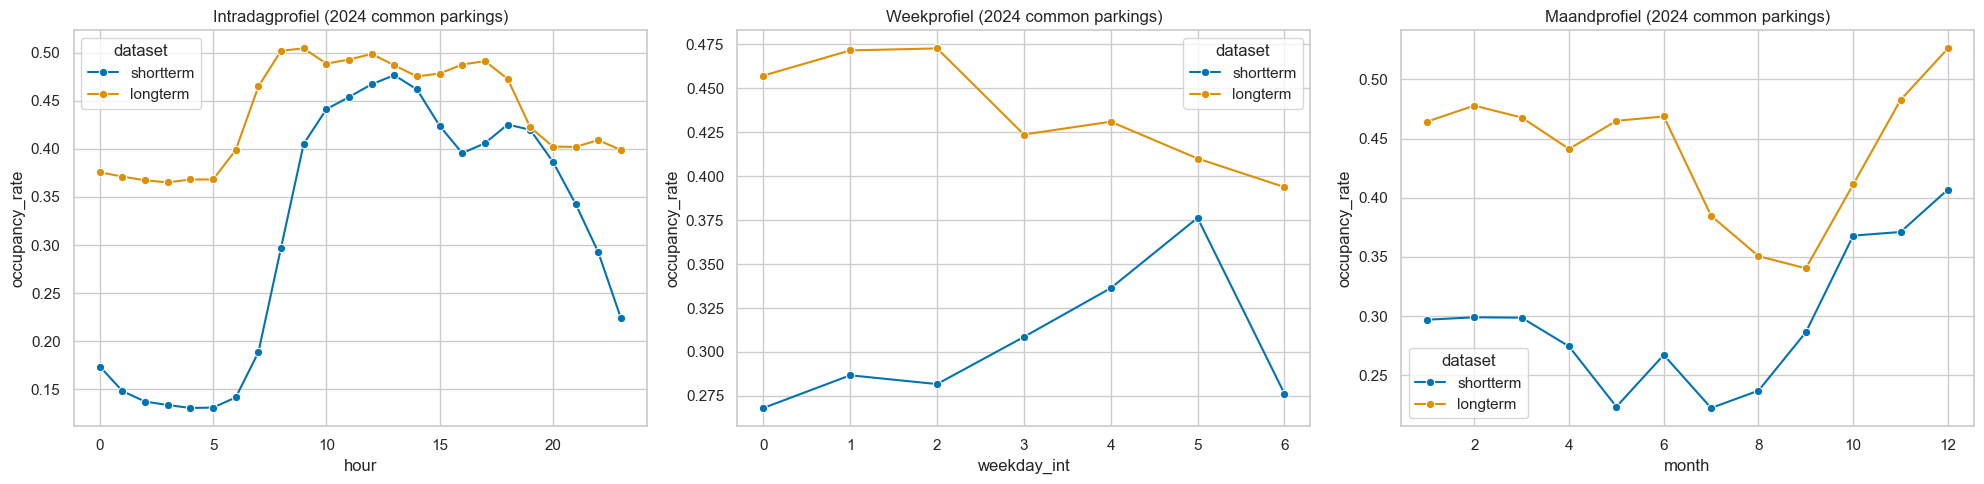

In [3]:
# Profielvergelijking: intradag, week, seizoen
profile_specs = [
    (["hour"], "intradag"),
    (["weekday_int"], "weekprofiel"),
    (["season"], "seizoensprofiel"),
    (["hour", "weekday_int"], "hour_x_weekday"),
]

profile_rows = []
for scope_name, obj in SCOPES.items():
    st_scope = obj["shortterm"]
    lt_scope = obj["longterm"]

    for group_cols, label in profile_specs:
        sim = profile_similarity(st_scope, lt_scope, group_cols)
        profile_rows.append(
            {
                "scope": scope_name,
                "profile": label,
                **sim,
            }
        )

profile_df = pd.DataFrame(profile_rows)

print("Profielsimilariteit")
display(profile_df.round(5))

# Visualisaties op faire scope
fair_scope = SCOPES["year2024_common_parkings"]
st_fair = fair_scope["shortterm"]
lt_fair = fair_scope["longterm"]

plot_specs = [
    ("hour", "Intradagprofiel"),
    ("weekday_int", "Weekprofiel"),
    ("month", "Maandprofiel"),
]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, (xcol, title) in zip(axes, plot_specs):
    st_prof = st_fair.groupby(xcol)["occupancy_rate"].mean().reset_index()
    lt_prof = lt_fair.groupby(xcol)["occupancy_rate"].mean().reset_index()
    st_prof["dataset"] = "shortterm"
    lt_prof["dataset"] = "longterm"
    p = pd.concat([st_prof, lt_prof], ignore_index=True)

    sns.lineplot(data=p, x=xcol, y="occupancy_rate", hue="dataset", marker="o", ax=ax)
    ax.set_title(f"{title} (2024 common parkings)")

plt.tight_layout()
plt.show()

**Interpretatie**

Longterm ligt in alle scopes op een hoger gemiddeld niveau dan shortterm, inclusief de faire 2024+common-parkings vergelijking. Tegelijk heeft longterm lager `std` en lagere piekfrequentie (`% >= 0.9`), maar niet consequent lagere IQR. Variabiliteit hangt dus af van gekozen spreidingsmaat.

Profielsimilariteit toont dat intradagpatronen gedeeltelijk overeenkomen, maar week- en seizoenspatronen duidelijk kunnen divergeren, vooral in 2024-vergelijkingen. Dit ondersteunt regimeverschil in gedragsstructuur.

**Hypothese status (tussenstand)**
- H-LT1: **Supported**.
- H-LT2: **Supported** (verschillen blijven bestaan in faire scope).
- H-LT3: **Partially supported** (lagere std en piekfrequentie, maar niet uniform lagere IQR).

**Volgende logische stap**
- Responsiviteit aan externe drivers vergelijken met maand-gecorrigeerde effectmaten.

## 2. Responsiviteit aan events, holidays, vacations en weather bins

In [4]:
binary_drivers = ["is_event_day", "is_any_holiday", "is_school_vacation"]

binary_rows = []
for scope_name, obj in SCOPES.items():
    for dataset_label in ["shortterm", "longterm"]:
        d = obj[dataset_label]
        for flag_col in binary_drivers:
            raw_flag = as_flag(d[flag_col])
            if int(raw_flag.sum()) < 20 or int((~raw_flag).sum()) < 20:
                raw_delta = np.nan
            else:
                raw_delta = float(d.loc[raw_flag, "occupancy_rate"].mean() - d.loc[~raw_flag, "occupancy_rate"].mean())

            month_delta = monthly_adjusted_delta(d, flag_col)
            binary_rows.append(
                {
                    "scope": scope_name,
                    "dataset": dataset_label,
                    "driver": flag_col,
                    "raw_delta": raw_delta,
                    "month_adjusted_delta": month_delta,
                }
            )

binary_df = pd.DataFrame(binary_rows)

# Weather sensitivity via binned Q5-Q1 deltas
weather_vars = ["temp_c", "precip_mm", "wind_speed_ms", "sun_duration_min", "humidity_pct"]
weather_rows = []

for scope_name, obj in SCOPES.items():
    for dataset_label in ["shortterm", "longterm"]:
        d = obj[dataset_label]

        for var in weather_vars:
            g = d[[var, "occupancy_rate"]].dropna().copy()
            if len(g) < 200:
                weather_rows.append(
                    {
                        "scope": scope_name,
                        "dataset": dataset_label,
                        "driver": var,
                        "q5_minus_q1_delta": np.nan,
                    }
                )
                continue

            try:
                g["q"] = pd.qcut(g[var], 5, labels=["Q1", "Q2", "Q3", "Q4", "Q5"], duplicates="drop")
            except ValueError:
                weather_rows.append(
                    {
                        "scope": scope_name,
                        "dataset": dataset_label,
                        "driver": var,
                        "q5_minus_q1_delta": np.nan,
                    }
                )
                continue

            means = g.groupby("q", observed=True)["occupancy_rate"].mean()
            if {"Q1", "Q5"}.issubset(set(means.index.astype(str))):
                delta = float(means.loc["Q5"] - means.loc["Q1"])
            else:
                delta = np.nan

            weather_rows.append(
                {
                    "scope": scope_name,
                    "dataset": dataset_label,
                    "driver": var,
                    "q5_minus_q1_delta": delta,
                }
            )

weather_df = pd.DataFrame(weather_rows)

# Precip fixed bins as non-linearity check
precip_bins = [-0.01, 0, 0.2, 1, 3, 8, 100]
precip_labels = ["0", "0-0.2", "0.2-1", "1-3", "3-8", "8+"]
precip_rows = []
for scope_name, obj in SCOPES.items():
    for dataset_label in ["shortterm", "longterm"]:
        d = obj[dataset_label]
        g = d[["precip_mm", "occupancy_rate"]].dropna().copy()
        g["precip_bin"] = pd.cut(g["precip_mm"], bins=precip_bins, labels=precip_labels)
        t = g.groupby("precip_bin", observed=True)["occupancy_rate"].agg(["count", "mean"]).reset_index()
        t["scope"] = scope_name
        t["dataset"] = dataset_label
        precip_rows.append(t)

precip_bin_df = pd.concat(precip_rows, ignore_index=True)

print("Binary driver deltas")
display(binary_df.round(5))

print("Weather Q5-Q1 deltas")
display(weather_df.round(5))

print("Precip bins")
display(precip_bin_df.round(5))

Binary driver deltas


,scope,dataset,driver,raw_delta,month_adjusted_delta
0,full_context,shortterm,is_event_day,0.01029,0.00607
1,full_context,shortterm,is_any_holiday,-0.02811,-0.02976
2,full_context,shortterm,is_school_vacation,-0.01918,-0.02135
3,full_context,longterm,is_event_day,-0.05204,-0.02575
4,full_context,longterm,is_any_holiday,-0.02337,-0.06357
5,full_context,longterm,is_school_vacation,-0.05379,-0.04004
6,year2024,shortterm,is_event_day,0.00398,0.03841
7,year2024,shortterm,is_any_holiday,0.00358,-0.00732
8,year2024,shortterm,is_school_vacation,-0.04822,-0.02176
9,year2024,longterm,is_event_day,-0.05204,-0.02575


Weather Q5-Q1 deltas


,scope,dataset,driver,q5_minus_q1_delta
0,full_context,shortterm,temp_c,0.06990
1,full_context,shortterm,precip_mm,NaN
2,full_context,shortterm,wind_speed_ms,0.08016
3,full_context,shortterm,sun_duration_min,NaN
4,full_context,shortterm,humidity_pct,-0.11972
5,full_context,longterm,temp_c,-0.06907
6,full_context,longterm,precip_mm,NaN
7,full_context,longterm,wind_speed_ms,0.07542
8,full_context,longterm,sun_duration_min,NaN
9,full_context,longterm,humidity_pct,-0.03329


Precip bins


,precip_bin,count,mean,scope,dataset
0,0,187892,0.37806,full_context,shortterm
1,0-0.2,13745,0.38172,full_context,shortterm
2,0.2-1,9900,0.36592,full_context,shortterm
3,1-3,4839,0.36761,full_context,shortterm
4,3-8,907,0.36059,full_context,shortterm
5,8+,154,0.34737,full_context,shortterm
6,0,39715,0.43436,full_context,longterm
7,0-0.2,2919,0.45403,full_context,longterm
8,0.2-1,2396,0.44917,full_context,longterm
9,1-3,1264,0.47033,full_context,longterm


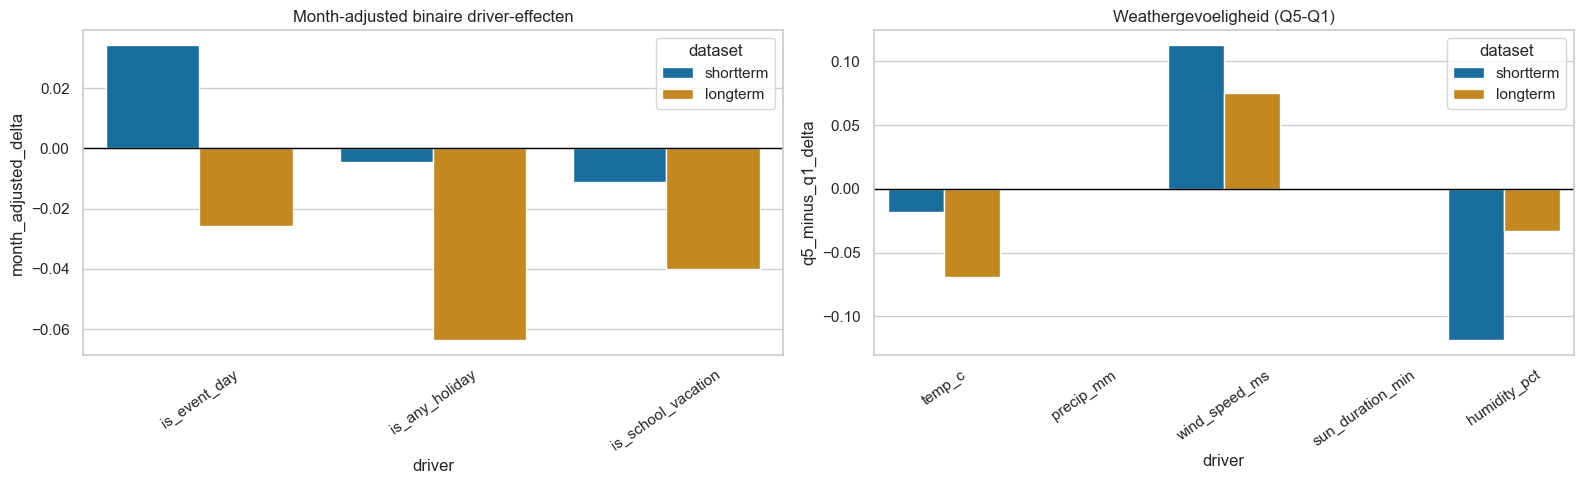

In [5]:
# Compacte visualisatie op faire scope
sub_bin = binary_df.loc[binary_df["scope"] == "year2024_common_parkings"].copy()
sub_wea = weather_df.loc[weather_df["scope"] == "year2024_common_parkings"].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=sub_bin, x="driver", y="month_adjusted_delta", hue="dataset", ax=axes[0])
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Month-adjusted binaire driver-effecten")
axes[0].tick_params(axis="x", rotation=35)

sns.barplot(data=sub_wea, x="driver", y="q5_minus_q1_delta", hue="dataset", ax=axes[1])
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Weathergevoeligheid (Q5-Q1)")
axes[1].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

**Interpretatie**

De richting en grootte van driver-effecten verschillen duidelijk tussen shortterm en longterm, ook in de faire scope. Vooral event- en holiday-responsiviteit vertonen sign-reversals of sterke magnitudeverschillen, wat wijst op regime-afhankelijke externe respons.

Weereffecten tonen eveneens een ander patroonprofiel tussen datasets. Dit ondersteunt het idee dat gedeelde featurefamilies mogelijk blijven, maar met dataset-specifieke parametrisatie/interacties.

**Hypothese status (tussenstand)**
- H-LT4: **Supported** (externe respons niet gelijk tussen regimes).

**Volgende logische stap**
- Correlatiestructuren en temporal memory vergelijken om structurele dynamiekverschillen te testen.

## 3. Correlatiestructuur en temporal memory

In [6]:
# 3.1 Temporal memory (ACF 24h/168h)
mem_rows = []
for scope_name, obj in SCOPES.items():
    for dataset_label in ["shortterm", "longterm"]:
        d = obj[dataset_label]
        ts, miss_pct = hourly_series(d)
        ac = acf(ts, nlags=168, fft=True)
        mem_rows.append(
            {
                "scope": scope_name,
                "dataset": dataset_label,
                "n_hours": int(len(ts)),
                "missing_pct_before_fill": miss_pct,
                "acf_24": float(ac[24]),
                "acf_168": float(ac[168]),
            }
        )

memory_df = pd.DataFrame(mem_rows)

print("Temporal memory")
display(memory_df.round(5))

# 3.2 Correlatiestructuur (faire scope + common parkings)
st_common = SCOPES["year2024_common_parkings"]["shortterm"]
lt_common = SCOPES["year2024_common_parkings"]["longterm"]

corr_st = standardized_week_profile_corr(st_common)
corr_lt = standardized_week_profile_corr(lt_common)

mean_offdiag_st = float(corr_st.where(~np.eye(len(corr_st), dtype=bool)).stack().mean())
mean_offdiag_lt = float(corr_lt.where(~np.eye(len(corr_lt), dtype=bool)).stack().mean())

corr_strength_df = pd.DataFrame(
    {
        "metric": ["mean_offdiag_corr_common_parkings"],
        "shortterm": [mean_offdiag_st],
        "longterm": [mean_offdiag_lt],
        "diff_lt_minus_st": [mean_offdiag_lt - mean_offdiag_st],
    }
)

print("Correlatiestructuursterkte")
display(corr_strength_df.round(5))

print("ST correlatiematrix (2024 common)")
display(corr_st.round(3))

print("LT correlatiematrix (2024 common)")
display(corr_lt.round(3))

Temporal memory


,scope,dataset,n_hours,missing_pct_before_fill,acf_24,acf_168
0,full_context,shortterm,61368,28.80003,0.83624,0.86347
1,full_context,longterm,8783,0.00000,0.73362,0.76881
2,year2024,shortterm,8784,0.00000,0.76802,0.83385
3,year2024,longterm,8783,0.00000,0.73362,0.76881
4,year2024_common_parkings,shortterm,8784,0.00000,0.77746,0.83587
5,year2024_common_parkings,longterm,8783,0.00000,0.73362,0.76881


Correlatiestructuursterkte


,metric,shortterm,longterm,diff_lt_minus_st
0,mean_offdiag_corr_common_parkings,0.64724,0.223,-0.42424


ST correlatiematrix (2024 common)


parking_id,P Grote Markt,P Hoogstraat,P Kathedraal,P Keerdok,P Komet,P Maarten,P Tinel
parking_id,,,,,,,
P Grote Markt,1.000,0.864,0.980,0.749,0.408,0.180,0.927
P Hoogstraat,0.864,1.000,0.882,0.881,0.715,0.403,0.935
P Kathedraal,0.980,0.882,1.000,0.762,0.430,0.165,0.951
P Keerdok,0.749,0.881,0.762,1.000,0.822,0.416,0.804
P Komet,0.408,0.715,0.430,0.822,1.000,0.574,0.517
P Maarten,0.180,0.403,0.165,0.416,0.574,1.000,0.227
P Tinel,0.927,0.935,0.951,0.804,0.517,0.227,1.000


LT correlatiematrix (2024 common)


parking_id,P Grote Markt,P Hoogstraat,P Kathedraal,P Keerdok,P Komet,P Maarten,P Tinel
parking_id,,,,,,,
P Grote Markt,1.000,0.283,0.768,0.662,-0.223,-0.408,0.685
P Hoogstraat,0.283,1.000,0.413,0.654,0.266,-0.015,0.401
P Kathedraal,0.768,0.413,1.000,0.836,-0.321,-0.575,0.629
P Keerdok,0.662,0.654,0.836,1.000,-0.198,-0.574,0.596
P Komet,-0.223,0.266,-0.321,-0.198,1.000,0.803,0.152
P Maarten,-0.408,-0.015,-0.575,-0.574,0.803,1.000,-0.154
P Tinel,0.685,0.401,0.629,0.596,0.152,-0.154,1.000


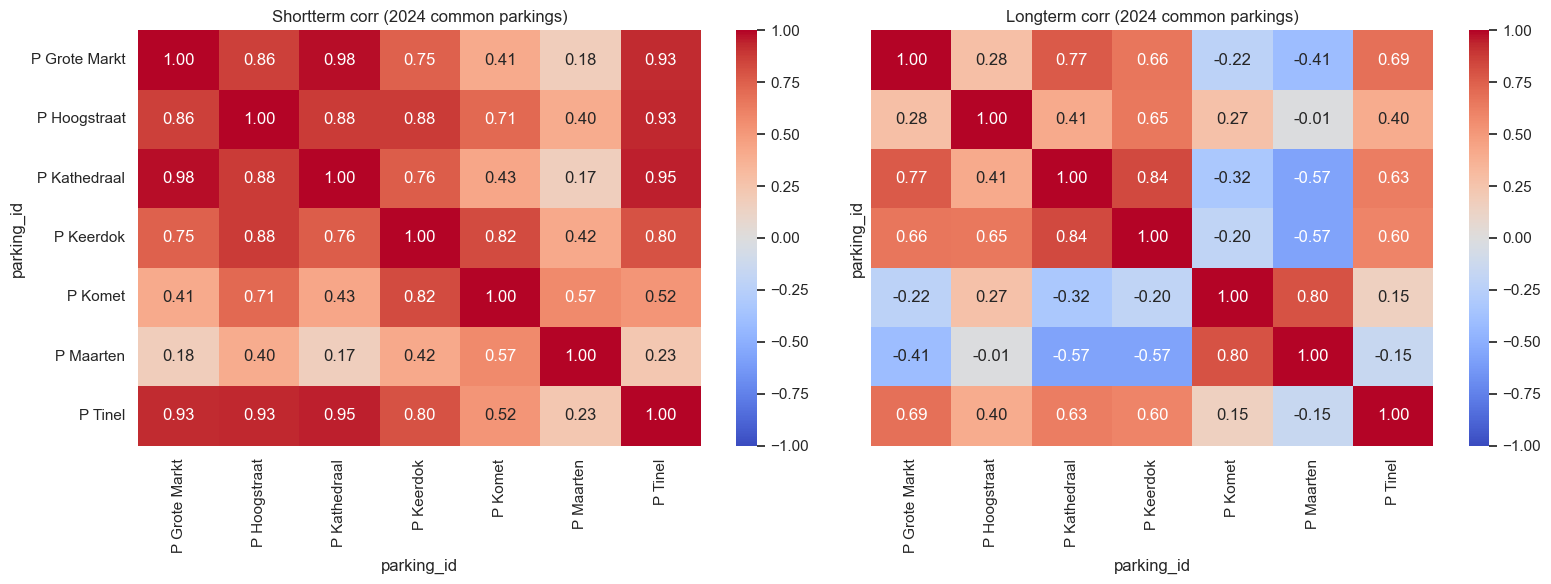

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

sns.heatmap(corr_st, vmin=-1, vmax=1, cmap="coolwarm", center=0, annot=True, fmt=".2f", ax=axes[0])
axes[0].set_title("Shortterm corr (2024 common parkings)")

sns.heatmap(corr_lt, vmin=-1, vmax=1, cmap="coolwarm", center=0, annot=True, fmt=".2f", ax=axes[1])
axes[1].set_title("Longterm corr (2024 common parkings)")

plt.tight_layout()
plt.show()

**Interpretatie**

Shortterm en longterm verschillen in temporal memory: longterm heeft in deze analyses lagere ACF op 24u/168u. Daarnaast is de parking-tot-parking correlatiestructuur in de faire scope veel compacter in shortterm dan in longterm.

Dat betekent dat “modelstructuur” (niet enkel featurewaarden) waarschijnlijk regimeafhankelijk is.

**Hypothese status (tussenstand)**
- H-LT5: **Supported**.

**Volgende logische stap**
- Systematisch toetsen of externe signalen gemiddeld sterker zijn in shortterm dan in longterm.

## 4. Zijn externe factoren sterker in shortterm?

In [8]:
# 4.1 Weather strength via month-centered |rho|
weather_strength_rows = []
ext_vars = ["temp_c", "precip_mm", "wind_speed_ms", "sun_duration_min", "humidity_pct"]

for scope_name, obj in SCOPES.items():
    for dataset_label in ["shortterm", "longterm"]:
        d = obj[dataset_label]
        abs_rhos = []
        for var in ext_vars:
            g = d[["month", var, "occupancy_rate"]].dropna().copy()
            if len(g) < 200:
                continue
            g["x_c"] = g[var] - g.groupby("month")[var].transform("mean")
            g["y_c"] = g["occupancy_rate"] - g.groupby("month")["occupancy_rate"].transform("mean")
            rho, _ = spearmanr(g["x_c"], g["y_c"])
            abs_rhos.append(abs(float(rho)))

        weather_strength_rows.append(
            {
                "scope": scope_name,
                "dataset": dataset_label,
                "mean_abs_month_centered_rho": float(np.mean(abs_rhos)) if abs_rhos else np.nan,
                "n_weather_vars": len(abs_rhos),
            }
        )

weather_strength_df = pd.DataFrame(weather_strength_rows)

# 4.2 Binary driver strength via |month-adjusted delta|
binary_strength_rows = []
for scope_name, obj in SCOPES.items():
    for dataset_label in ["shortterm", "longterm"]:
        d = obj[dataset_label]
        deltas = []
        for flag in ["is_event_day", "is_any_holiday", "is_school_vacation"]:
            delta = monthly_adjusted_delta(d, flag)
            if pd.notna(delta):
                deltas.append(abs(float(delta)))

        binary_strength_rows.append(
            {
                "scope": scope_name,
                "dataset": dataset_label,
                "mean_abs_month_adjusted_binary_delta": float(np.mean(deltas)) if deltas else np.nan,
                "n_binary_drivers": len(deltas),
            }
        )

binary_strength_df = pd.DataFrame(binary_strength_rows)

strength_merge = weather_strength_df.merge(binary_strength_df, on=["scope", "dataset"], how="outer")

# ratios LT/ST per scope
ratio_rows = []
for scope_name, grp in strength_merge.groupby("scope"):
    st_row = grp.loc[grp["dataset"] == "shortterm"].iloc[0]
    lt_row = grp.loc[grp["dataset"] == "longterm"].iloc[0]

    ratio_rows.append(
        {
            "scope": scope_name,
            "lt_over_st_weather_strength": float(lt_row["mean_abs_month_centered_rho"] / st_row["mean_abs_month_centered_rho"]),
            "lt_over_st_binary_strength": float(lt_row["mean_abs_month_adjusted_binary_delta"] / st_row["mean_abs_month_adjusted_binary_delta"]),
        }
    )

strength_ratio_df = pd.DataFrame(ratio_rows)

print("Strength summary")
display(strength_merge.round(6))

print("LT/ST strength ratios")
display(strength_ratio_df.round(6))

Strength summary


,scope,dataset,mean_abs_month_centered_rho,n_weather_vars,mean_abs_month_adjusted_binary_delta,n_binary_drivers
0,full_context,longterm,0.074364,5,0.043116,3
1,full_context,shortterm,0.115535,5,0.019061,3
2,year2024,longterm,0.074364,5,0.043116,3
3,year2024,shortterm,0.146485,5,0.022495,3
4,year2024_common_parkings,longterm,0.074364,5,0.043116,3
5,year2024_common_parkings,shortterm,0.141983,5,0.016648,3


LT/ST strength ratios


,scope,lt_over_st_weather_strength,lt_over_st_binary_strength
0,full_context,0.643647,2.262004
1,year2024,0.507654,1.916705
2,year2024_common_parkings,0.523754,2.589862


**Interpretatie**

Gemiddeld is de externe gevoeligheid (vooral weather) in longterm lager dan in shortterm in alle scopes. Voor binaire drivers is het beeld gemengd maar doorgaans ook niet sterker in longterm.

Belangrijk: “sterker in shortterm” geldt niet voor elke individuele driver en elk segment. We houden dit dus als patroon op aggregatieniveau, niet als universele regel.

**Hypothese status**
- H-LT4: **Partially to strongly supported** (duidelijk op weather-aggregaat, gemengd op individuele binaries).

**Volgende logische stap**
- Beslissingsgerichte conclusie formuleren voor Phase 3/4, inclusief LT-go/no-go.

## 5. Operationele conclusie voor Phase 3

In [9]:
# Longterm representativiteitsdiagnostiek
lt_diag = filtered_dfs["longterm"].copy()

hours_2024 = 366 * 24
lt_coverage = (
    lt_diag.groupby("parking_id")["rounded_hour"]
    .nunique()
    .div(hours_2024)
    .mul(100)
    .rename("coverage_pct_of_2024")
    .sort_values()
)

lt_diag_table = pd.DataFrame(
    {
        "metric": [
            "n_rows",
            "n_parkings",
            "n_years",
            "year_min",
            "year_max",
            "min_obs_per_parking",
            "max_obs_per_parking",
            "obs_P_Tinel",
            "pct_P_Tinel_of_LT",
        ],
        "value": [
            int(len(lt_diag)),
            int(lt_diag["parking_id"].nunique()),
            int(lt_diag["year"].nunique()),
            int(lt_diag["year"].min()),
            int(lt_diag["year"].max()),
            int(lt_diag["parking_id"].value_counts().min()),
            int(lt_diag["parking_id"].value_counts().max()),
            int((lt_diag["parking_id"] == "P Tinel").sum()),
            float((lt_diag["parking_id"] == "P Tinel").mean() * 100),
        ],
    }
)

print("Longterm representativiteitsdiagnostiek")
display(lt_diag_table)

print("Longterm parking coverage (% van alle uren in 2024)")
display(lt_coverage.round(4).to_frame())

Longterm representativiteitsdiagnostiek


,metric,value
0,n_rows,46643.000000
1,n_parkings,7.000000
2,n_years,1.000000
3,year_min,2024.000000
4,year_max,2024.000000
5,min_obs_per_parking,302.000000
6,max_obs_per_parking,8750.000000
7,obs_P_Tinel,302.000000
8,pct_P_Tinel_of_LT,0.647471


Longterm parking coverage (% van alle uren in 2024)


,coverage_pct_of_2024
parking_id,
P Tinel,3.4381
P Maarten,67.7140
P Komet,67.8734
P Grote Markt,96.4367
P Hoogstraat,96.5733
P Kathedraal,99.3511
P Keerdok,99.6129


### Beslissing: gezamenlijk of apart modelleren?

De analyses ondersteunen **aparte modellering of minimaal aparte featurebehandeling** voor shortterm en longterm. De datasets verschillen op niveau, responsiviteit, correlatiestructuur en memory. Een gezamenlijk model met uniforme aannames is daarom risicovol.

### Beslissing over LT in vervolg (Phase 3/4)

**Aanbevolen operationele keuze:**
1. **Primary track:** focus op shortterm voor hoofdmodellen, featureselectie en evaluatie in de thesis.
2. **Longterm track:** enkel als secundaire/supplementaire analyse (bijv. robustness appendix), niet als primaire trainingsbron.

**Onderbouwing:**
- longterm bevat slechts één jaar (2024), dus geen robuuste interjaarse generalisatie.
- beperkte omvang en coverage-onbalans (bv. zeer lage dekking voor `P Tinel`) beperken representativiteit.
- meerdere effectrichtingen divergeren tussen ST en LT; samenvoegen verhoogt modelmismatch-risico.

### Feature-engineering implicaties

1. Behoud gedeelde featurefamilies (tijd, events, calendar, weather), maar parametriseer dataset-specifiek.
2. Gebruik voor shortterm rijkere temporal/external interacties (meer data, hogere gevoeligheid).
3. Voor eventuele longterm-analyse: eenvoudiger, robuuste set met sterke regularisatie en expliciete coverage-flags.
4. Documenteer expliciet dat LT niet uit “onbruikbaarheid”, maar uit **beperkte onderzoekswaarde voor primaire voorspellingsdoelen** uit de hoofdtrack wordt gelaten.

## Hypothese-overzicht

- **H-LT1**: supported.
`shortterm` en `longterm` tonen structureel verschillende bezettingsregimes.

- **H-LT2**: supported.
Verschillen blijven zichtbaar in de faire vergelijking (2024 + common parkings).

- **H-LT3**: partially supported.
`longterm` heeft lagere `std` en piekfrequentie, maar niet consequent lagere IQR.

- **H-LT4**: partially to strongly supported.
Externe gevoeligheid is gemiddeld lager in LT (vooral weather), maar niet uniform per driver.

- **H-LT5**: supported.
Temporal memory en correlatiestructuur verschillen duidelijk.

- **H-LT6**: supported.
LT is methodologisch onvoldoende sterk voor primaire Phase 3/4-modellering, maar bruikbaar als secundaire robustness-track.

## Key findings
1. ST en LT vormen verschillende gedragsregimes, ook onder faire vergelijkingsrestricties.
2. LT heeft doorgaans lagere piekintensiteit en andere dynamiek-/responsstructuur dan ST.
3. Externe effecten zijn niet stabiel overdraagbaar tussen ST en LT.
4. LT (1 jaar, beperkte en oneven coverage) is zwak als primaire modelbasis voor de thesis-hoofdtrack.

## Implications for feature engineering
1. Bouw de primaire feature pipeline voor shortterm en gebruik LT enkel secundair.
2. Gebruik gedeelde featurefamilies, maar met dataset-specifieke interacties/regularisatie.
3. Leg fairness-scopes vast (tijd + parkingoverlap) voor elke ST-LT vergelijking in volgende notebooks.
4. Voeg coverage- en representativiteitschecks als vaste rapporteringslaag toe.

## Open questions for next notebook
1. Welke shortterm-features blijven stabiel in strikte year-based holdouts?
2. Welk minimaal LT-featurepakket blijft nog zinvol in een robustness-track?
3. Hoeveel performanceverlies/gain geeft strikt gescheiden versus gedeeltelijk gedeelde modellering?
4. Welke interacties zijn essentieel voor ST, maar overfitting-gevoelig voor LT?